In [29]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm,gamma
from scipy import integrate
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [30]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./real/{fileName}')
    df4 = pd.DataFrame(arff_file[0])
    #drop the outlier and id columns for the independent variables.
    X = df4.drop(columns=['outlier','id']).values
    #get outlier values
    y = df4['outlier'].values
    le = LabelEncoder()
    #encoded the variables as 0=non-outlier, 1=outlier
    y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, median='median'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if median == 'median':
            arr += [np.median(x)]
        elif median == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif median == 'max':
            arr += [np.max(x)]
        elif median == 'minMax':
            arr += [np.max(x) + x[1]]
        elif median == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif median == 'min':
            arr += [x[1]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v)
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="medMax")
        #arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr))
        means = np.mean(arr)
        inMean = 1 / means
        alpha = pow(np.mean(arr),2) / np.var(arr)
        beta = np.var(arr) / np.mean(arr)
        params = gamma.fit(arr)
        posNeg4 = []
        spaceStep4 = np.linspace(.9,.99,20)
        for e in spaceStep4:
            #newArr = arr > gamma.ppf(e,alpha,scale=beta)
            newArr = arr > gamma.ppf(e,params[0],loc=params[1], scale=params[2])
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        arrtest1 = arrtest1.flatten()
        arrtest2 = arrtest2.flatten()
        arrtest1 = (arrtest1-np.min(arrtest1))/(np.max(arrtest1)-np.min(arrtest1)) # normalize the results for ease of use
        arrtest2 = (arrtest2-np.min(arrtest2))/(np.max(arrtest2)-np.min(arrtest2))
        arrtest2 = np.nan_to_num(arrtest2)
        if np.sum(arrtest2) == 0: # if there are zero false positives than return zero
            tots += [1]
        else:
            tots += [integrate.trapezoid(arrtest1, x=-arrtest2)]

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def goodnessOfFit(X,y,kValue):
    knn, distReturn = main(X, y, kValue) # return knn and distance
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax") #
    print(skew(arr)) # check for skewness
    params = gamma.fit(arr) # fit the arr generated and get the params
    test = np.linspace(min(arr),max(arr),10)
    # pdfTest = expon.pdf(test,params[0],params[1]) #line used to test the pdf form

    values, edges = np.histogram(arr, bins=int(np.sqrt(len(arr))), density=True) #get values from bins and the edges
    #print(values, edges)
    newX = edges[:-1] + np.diff(edges) # X values from the bins

    pdf_fitted = gamma.pdf(newX,params[0], loc=params[1], scale=params[2]) # generate a new pdf using the new X values
    residuals = values - pdf_fitted # values vs the generated pdf
    print(pdf_fitted)
    #print(np.dot(residuals, residuals))
    print(sum(pow(residuals, 2) / pdf_fitted)) # prints the chi squared value
    plt.scatter(edges[:-1], values)
    plt.scatter(edges[:-1], pdf_fitted)
    plt.show()

0.9000000000000001 3 [0.8925000000000001, 0.9000000000000001, 0.8944444444444445, 0.8774509803921567, 0.8725490196078431, 0.777027027027027, 0.7638888888888888, 0.7638888888888888, 0.777027027027027, 0.7837837837837838, 0.736111111111111, 0.8055555555555556, 0.8142857142857143, 0.8285714285714285, 0.8235294117647058, 0.8285714285714285, 0.8124999999999999, 0.8285714285714285, 0.8308823529411764, 0.8285714285714285, 0.8357142857142857, 0.8194444444444444, 0.8428571428571429, 0.8428571428571429, 0.8472222222222222, 0.8402777777777778, 0.8541666666666666, 0.8888888888888888, 0.8888888888888888, 0.8819444444444444, 0.8819444444444444, 0.8819444444444444, 0.8819444444444444, 0.8999999999999999, 0.8999999999999999, 0.8819444444444444, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.8928571428571428, 0.7714285714285714, 0.7714285714285714, 0.8428571428571427, 0.857142857142857, 0.8428571428571427, 0.8333333333333333, 0.8194444444444444, 0.8333333333333333, 0.8194444444444444, 0.

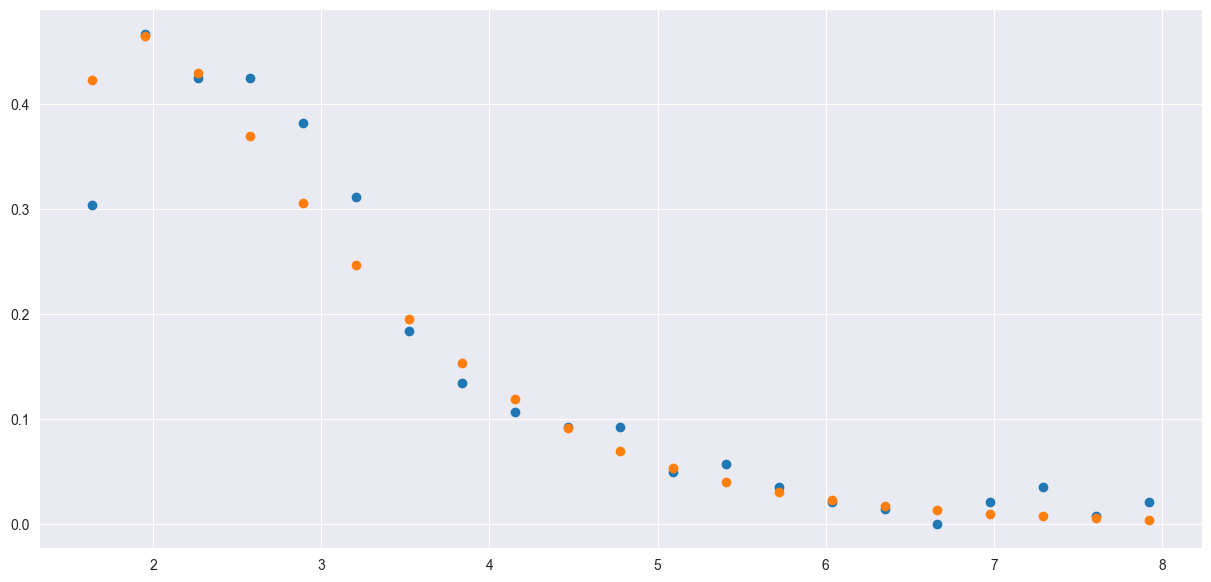

In [31]:
X, y = setupDf("Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,4)

1.0 3 [0.6666666666666667, 1.0, 1.0, 0.7727272727272727, 0.5000000000000001, 0.7272727272727272, 0.9, 0.925, 0.7727272727272727, 1.0, 0.8181818181818181, 0.7954545454545454, 0.8409090909090908, 1.0, 0.8181818181818181, 0.7954545454545454, 1.0, 0.75, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9615384615384615, 0.8555555555555554, 1.0, 0.9615384615384615, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8928571428571428, 0.9583333333333334, 0.923076923076923, 0.9583333333333334, 0.9583333333333334, 0.8846153846153846, 0.8461538461538461, 0.8333333333333333, 1.0, 1.0]
2.0166438330455088
[1.51349757 2.12586581 1.85553181 1.29441668 0.79219718 0.4449071
 0.23512938 0.11876292 0.05792125 0.02747062 0.01273526 0.00579328
 0.00259357]
5.103805521935946


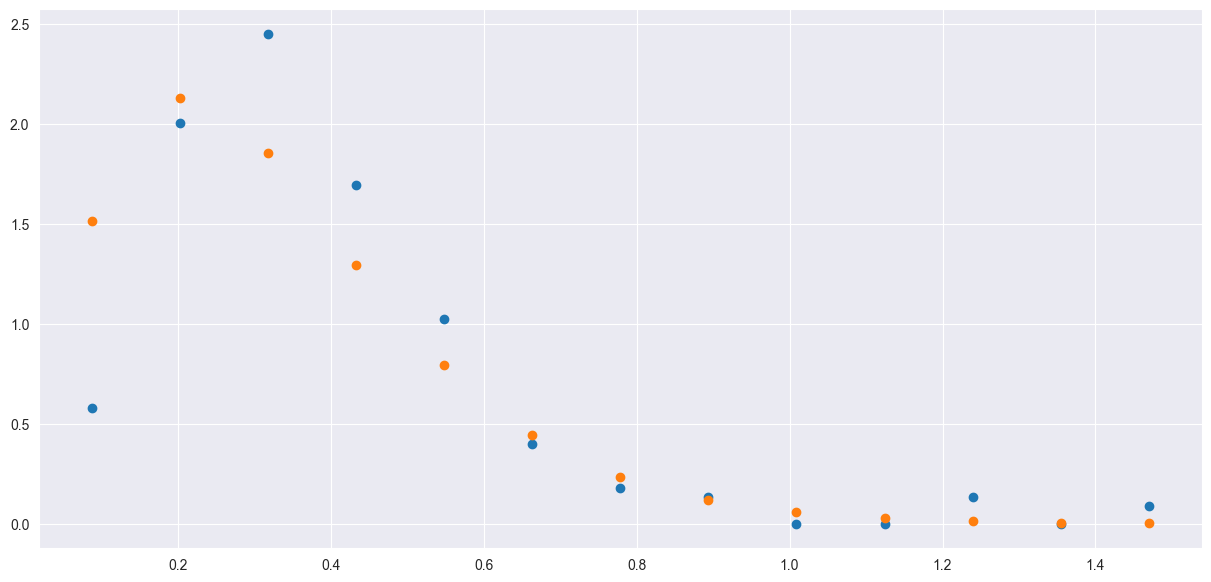

In [32]:
X, y = setupDf("Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,2)

1.0 17 [0.9453125, 0.8287937743190662, 0.5483870967741935, 0.875, 0.0, 0.5093333333333333, 0.6286407766990292, 0.9527027027027026, 0.962962962962963, 0.8679245283018868, 0.0, 0.9512195121951219, 0.6395348837209301, 0.875, 0.4833333333333334, 1.0, 0.6354166666666667, 0.8301886792452831, 0.8125, 0.7583333333333333, 0.7155172413793103, 0.0, 0.6929824561403508, 0.7543859649122807, 0.8416666666666666, 0.7272727272727273, 0.8362068965517242, 0.7327586206896551, 0.7083333333333333, 0.7327586206896551, 0.7166666666666666, 0.7416666666666666, 0.8666666666666666, 0.864406779661017, 0.7678571428571429, 0.8333333333333334, 0.8303571428571428, 0.7380952380952381, 0.7580645161290323, 0.6929824561403508, 0.6639344262295082, 0.8333333333333333, 0.6724137931034482, 0.8679245283018867, 0.8679245283018868, 0.8727272727272727, 0.8534482758620688, 0.8333333333333333, 0.7903225806451613, 0.8688524590163935, 0.8688524590163935, 0.5714285714285714, 0.7868852459016393, 0.8064516129032258, 0.8852459016393442, 0

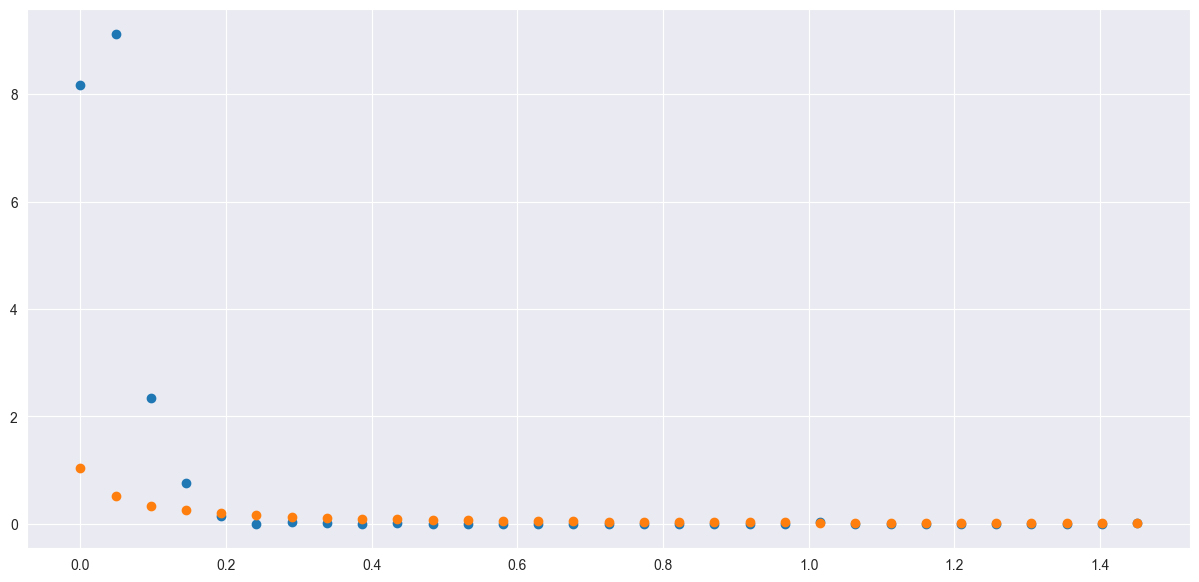

In [33]:
X, y = setupDf("Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,2)

0.9691358024691357 2 [0.9691358024691357, 0.6759259259259259, 0.805, 0.7944444444444444, 0.9074074074074073, 0.8596491228070176, 0.692982456140351, 0.6052631578947368, 0.8815789473684211, 0.8596491228070176, 0.7916666666666669, 0.7666666666666668, 0.7236842105263158, 0.8833333333333333, 0.9166666666666667, 0.9058823529411765, 0.8941176470588236, 0.8750000000000001, 0.7894736842105263, 0.8823529411764707, 0.9313725490196079, 0.921875, 0.9330357142857144, 0.9330357142857143, 0.9330357142857144, 0.926470588235294, 0.9313725490196079, 0.9322916666666667, 0.9419642857142858, 0.9362745098039216, 0.9428571428571428, 0.9322916666666667, 0.9464285714285716, 0.9427083333333335, 0.9464285714285714, 0.9476190476190478, 0.9411764705882353, 0.9333333333333333, 0.9428571428571431, 0.9428571428571431, 0.925, 0.8235294117647058, 0.9476190476190478, 0.9375, 0.823529411764706, 0.9476190476190478, 0.6666666666666666, 0.925, 0.9428571428571428, 0.9428571428571431, 0.6944444444444444, 0.9166666666666665, 0.

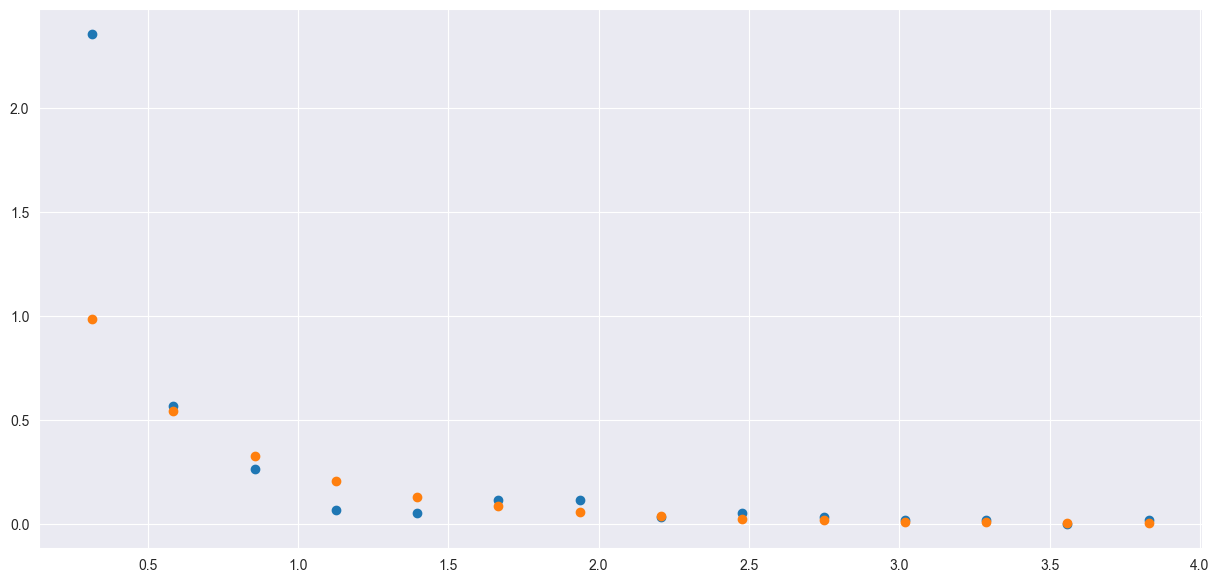

In [34]:
X, y = setupDf("WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,25)

0.509064056527279 5 [0.461953378429351, 0.46417281348788203, 0.48192697891987135, 0.509064056527279, 0.4643247510323051, 0.4595375722543353, 0.4525818954738685, 0.4319284414796847, 0.42315476190476203, 0.45074370709382156, 0.47640942420964066, 0.48212891211629727, 0.49350503919372907, 0.46691606266074354, 0.4499972389419626, 0.4439893862482694, 0.44972497249724974, 0.4614606741573034, 0.4720228718128245, 0.4626943005181347, 0.46281453867660766, 0.46323529411764697, 0.4704389826363415, 0.46222877865879897, 0.47947908445146004, 0.490381982475356, 0.48374178532311074, 0.4770114942528737, 0.4690992767915845, 0.4659339856871624, 0.470059880239521, 0.49922767995057155, 0.5033249882647474, 0.4944453137224223, 0.4792929292929293, 0.4613542835765058, 0.44466488709328333, 0.4730263157894736, 0.4803263302288643, 0.47507440476190477, 0.4690548780487805, 0.47067018072289163, 0.4752338196782642, 0.4940119760479041, 0.4978761198640718, 0.49401709401709404, 0.49532746370095776, 0.4891489033055299, 0.4

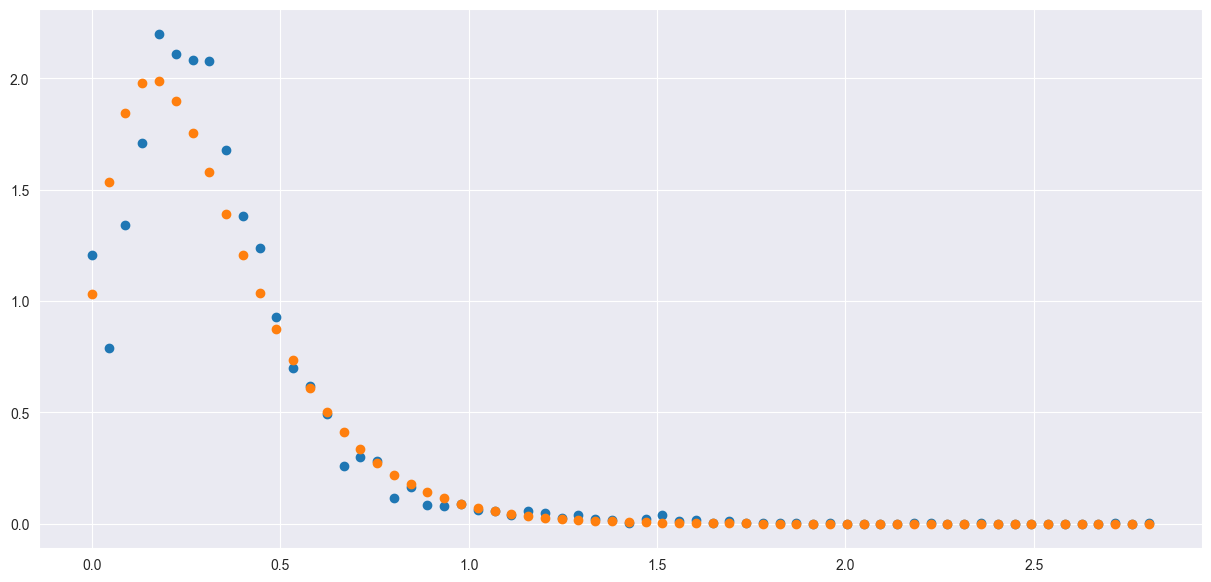

In [35]:
X, y = setupDf("SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,6)

0.8333333333333334 67 [0.75, 0.7500000000000001, 0.75, 0.5333333333333332, 0.511904761904762, 0.796875, 0.8055555555555556, 0.8125, 0.7916666666666665, 0.5196078431372549, 0.44852941176470595, 0.6764705882352942, 0.6862745098039216, 0.5588235294117647, 0.5882352941176471, 0.6328125, 0.6691176470588236, 0.6691176470588236, 0.6764705882352942, 0.6911764705882353, 0.6691176470588236, 0.6838235294117647, 0.6911764705882353, 0.6764705882352942, 0.7013888888888888, 0.7013888888888888, 0.6944444444444444, 0.75, 0.7222222222222221, 0.7152777777777777, 0.7361111111111112, 0.7430555555555555, 0.7569444444444444, 0.7708333333333333, 0.7569444444444444, 0.7569444444444444, 0.764705882352941, 0.7421875, 0.796875, 0.7999999999999998, 0.7916666666666665, 0.7833333333333332, 0.8046875, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7333333333333334, 0.7333333333333334, 0.7738095238095237,

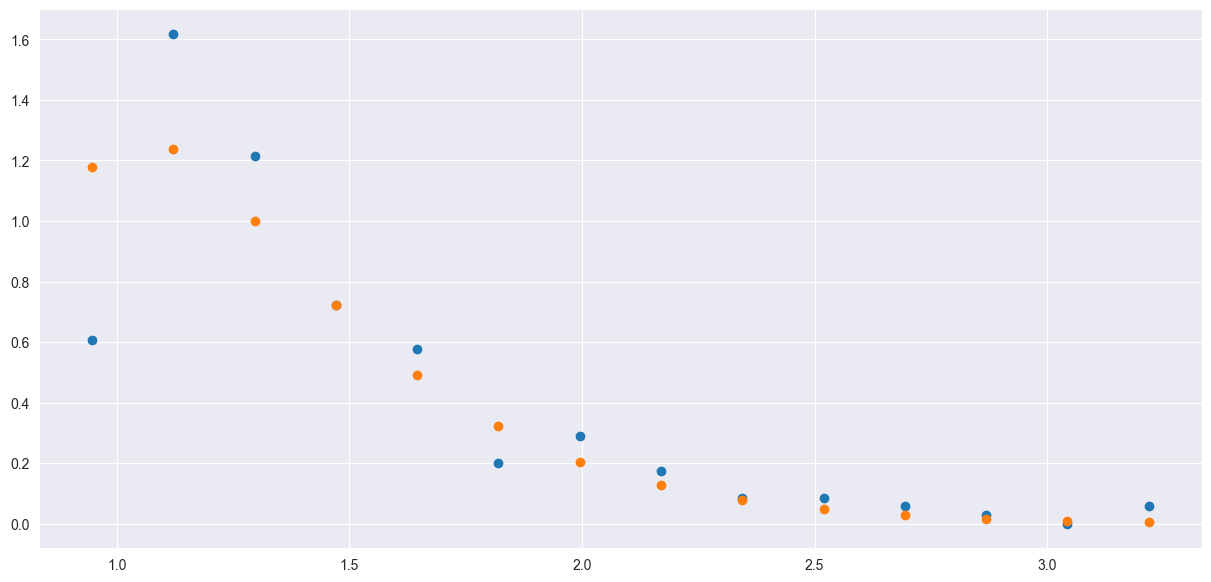

In [36]:
X, y = setupDf("WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 8)

0.6893382352941175 9 [0.37647058823529417, 0.6323529411764707, 0.6059027777777778, 0.6127450980392157, 0.6416666666666667, 0.5974264705882353, 0.6071428571428571, 0.6893382352941175, 0.6743697478991597, 0.6778846153846154, 0.6363636363636365, 0.6730769230769231, 0.6493506493506493, 0.6346153846153847, 0.5446428571428572, 0.5205128205128206, 0.4289772727272727, 0.484375, 0.4713541666666667, 0.41233766233766234, 0.34242424242424246, 0.4090909090909091, 0.46875, 0.6174242424242424, 0.6423611111111112, 0.5505952380952381, 0.49479166666666663, 0.5, 0.40374331550802145, 0.38181818181818183, 0.35795454545454547, 0.3787878787878788, 0.40584415584415584, 0.44047619047619047, 0.45238095238095233, 0.3928571428571429, 0.29545454545454547, 0.31493506493506496, 0.32867132867132876, 0.38141025641025644, 0.38141025641025644, 0.36309523809523814, 0.36011904761904767, 0.3571428571428571, 0.375, 0.39487179487179486, 0.39743589743589747, 0.44761904761904764, 0.44523809523809527, 0.484375, 0.42410714285714

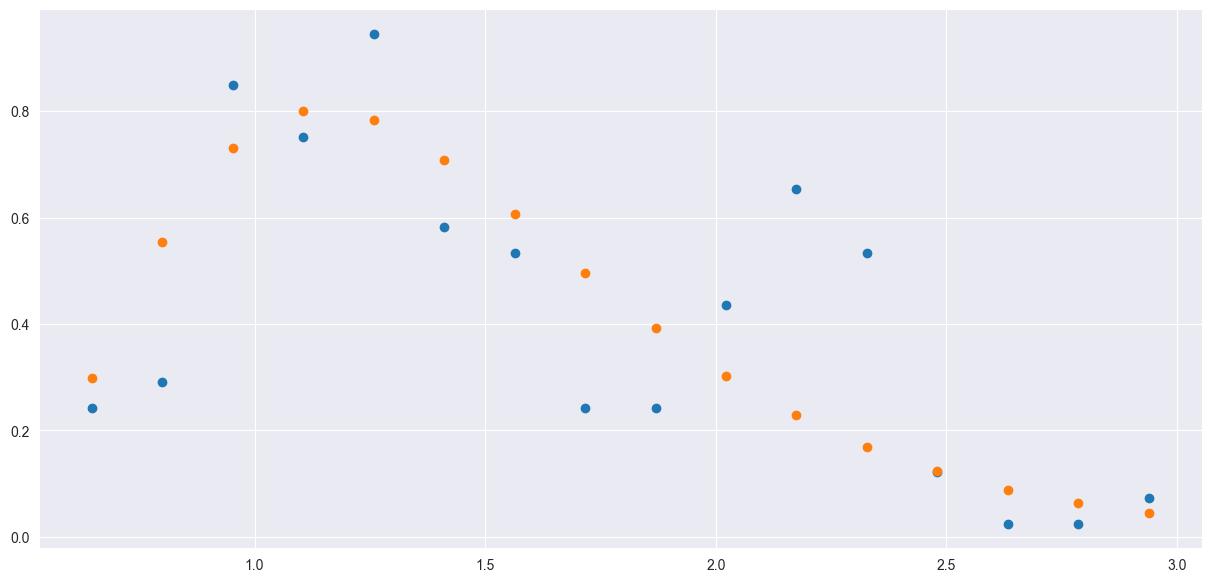

In [37]:
X, y = setupDf("HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 11)

0.8425925925925927 58 [0.33333333333333326, 0.38281249999999994, 0.3666666666666666, 0.5735294117647058, 0.5357142857142857, 0.6333333333333333, 0.6176470588235294, 0.631578947368421, 0.5555555555555556, 0.4444444444444444, 0.4444444444444444, 0.3777777777777778, 0.3666666666666667, 0.4027777777777778, 0.5098039215686274, 0.3666666666666667, 0.28205128205128205, 0.49999999999999994, 0.56140350877193, 0.5125, 0.3194444444444444, 0.6111111111111112, 0.5208333333333334, 0.5, 0.49999999999999994, 0.5208333333333333, 0.5614035087719298, 0.4333333333333333, 0.4705882352941176, 0.48148148148148134, 0.6499999999999999, 0.6406249999999999, 0.6166666666666665, 0.5104166666666666, 0.53125, 0.4903846153846154, 0.55, 0.6527777777777777, 0.4833333333333333, 0.42307692307692313, 0.4537037037037037, 0.5882352941176471, 0.671875, 0.59375, 0.4, 0.39743589743589747, 0.3782051282051282, 0.2642045454545454, 0.7749999999999999, 0.25, 0.6428571428571428, 0.31007751937984496, 0.3023255813953489, 0.29829545454

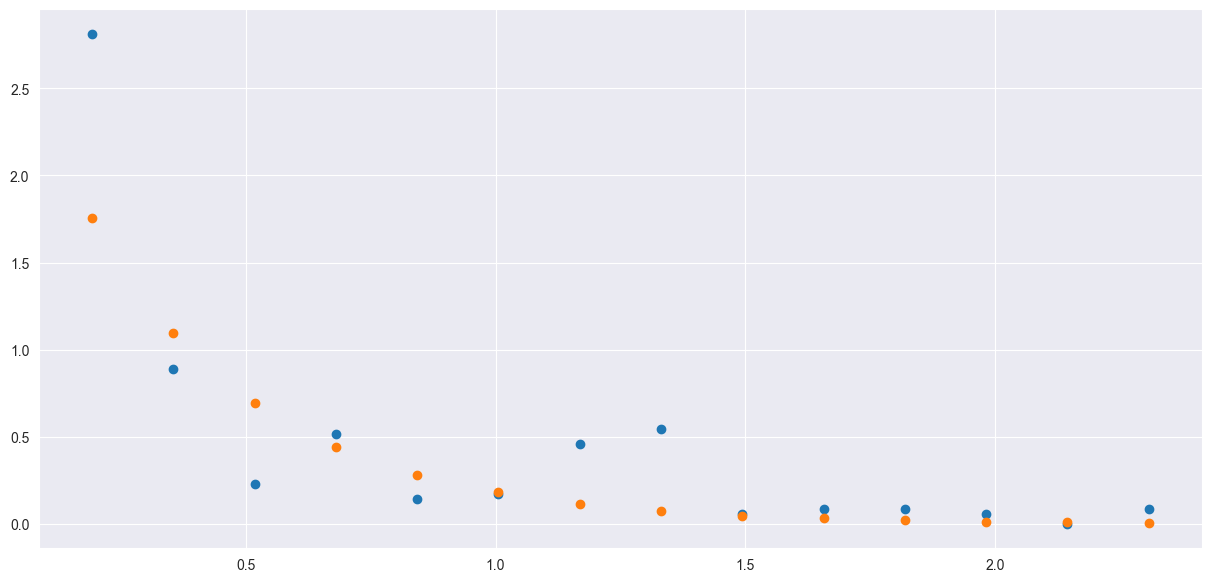

In [38]:
X, y = setupDf("Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 65)

0.6 58 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.33333333333333326, 0.33333333333333326, 0.25, 0.2857142857142857, 0.2857142857142857, 0.16666666666666674, 0.08333333333333337, 0.16666666666666674, 0.16666666666666674, 0.3214285714285714, 0.4285714285714286, 0.4285714285714286, 0.39583333333333326, 0.45833333333333326, 0.47916666666666663, 0.30000000000000004, 0.0, 0.0, 0.25, 0.25, 0.375, 0.25, 0.4642857142857143, 0.4642857142857143, 0.4642857142857143, 0.4285714285714286, 0.4166666666666667, 0.375, 0.375, 0.2777777777777778, 0.49999999999999994, 0.42857142857142855, 0.49999999999999994, 0.5, 0.5, 0.6, 0.6, 0.3333333333333333, 0.30952380952380953, 0.3571428571428572, 0.40476190476190477, 0.38095238095238093, 0.4047619047619047, 0.45833333333333337, 0.43749999999999994, 0.38095238095238093, 0.3611111111111111]
0.25471436592557123
[0.9523375  0.8358667  0.64783327 0.47636763 0.34019336 0.23845969
 0.16500196 0.11309368]
1.

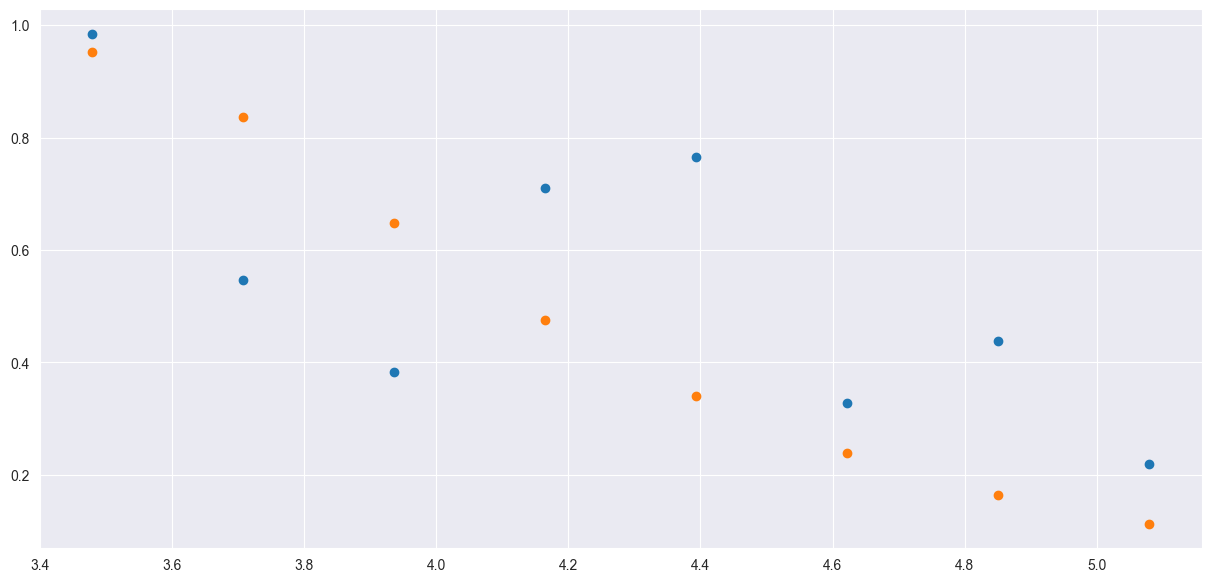

In [39]:
X, y = setupDf("Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 40)

0.5839947089947088 7 [0.2608695652173914, 0.3321428571428572, 0.4891428571428571, 0.5594444444444446, 0.5356321839080459, 0.5839947089947088, 0.5813793103448277, 0.563701923076923, 0.5296296296296295, 0.5328554360812425, 0.48263888888888884, 0.45794930875576034, 0.4718390804597701, 0.4212643678160918, 0.40555555555555545, 0.39179548156956, 0.3946236559139784, 0.38431590656284764, 0.36314655172413784, 0.3826473859844271, 0.35100446428571414, 0.3859375, 0.4166666666666667, 0.4455645161290323, 0.4599609375, 0.4408602150537635, 0.4236559139784946, 0.40722222222222215, 0.4466073414905451, 0.45297619047619037, 0.4559523809523809, 0.456547619047619, 0.4488095238095237, 0.4244444444444444, 0.42388888888888887, 0.41222222222222216, 0.41666666666666663, 0.4155555555555555, 0.4446236559139785, 0.4375650364203954, 0.40260416666666665, 0.4450604838709677, 0.4354838709677419, 0.40140086206896547, 0.387669801462905, 0.3949843260188088, 0.38133874239350907, 0.3847290640394089, 0.36916835699797157, 0.3

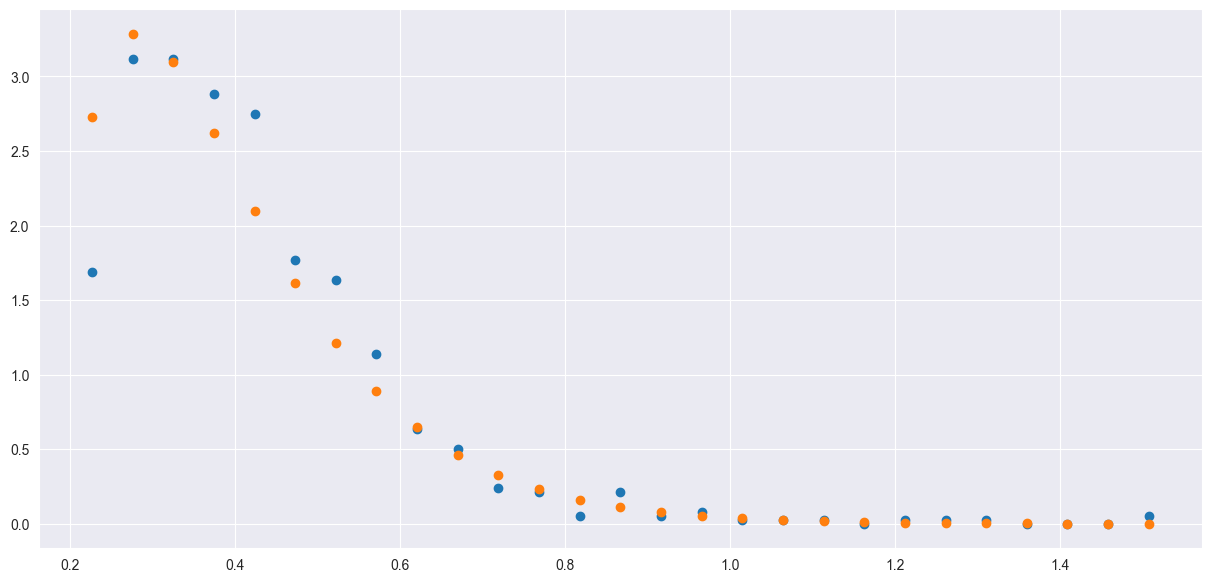

In [40]:
X, y = setupDf("Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 7)

0.9537767756482526 11 [0.7370443349753695, 0.6534229828850855, 0.8389751758927386, 0.8023529411764705, 0.8445475638051044, 0.9427745664739884, 0.9463276836158191, 0.9374307862679954, 0.9492509363295879, 0.9537767756482526, 0.9473830734966593, 0.9174008810572688, 0.9145742358078601, 0.9178610804851158, 0.888706140350877, 0.8940818584070797, 0.8654891304347825, 0.8653217011995636, 0.8687904967602591, 0.8686000716075903, 0.8952738990332975, 0.8640862495581477, 0.89026008492569, 0.8915421558164354, 0.8914021164021162, 0.9122105263157895, 0.8995824634655532, 0.9027979274611398, 0.8816390041493776, 0.8825726141078838, 0.8850311850311849, 0.8645768025078369, 0.8605263157894737, 0.8591858037578287, 0.8582635983263598, 0.8625922023182298, 0.8634453781512605, 0.8556494192185851, 0.8436903499469778, 0.8420274551214361, 0.8347734457323499, 0.8361904761904762, 0.8384371700105596, 0.841595744680851, 0.8334408602150538, 0.8260729613733905, 0.8185265438786565, 0.8106243154435925, 0.8143487858719647, 0

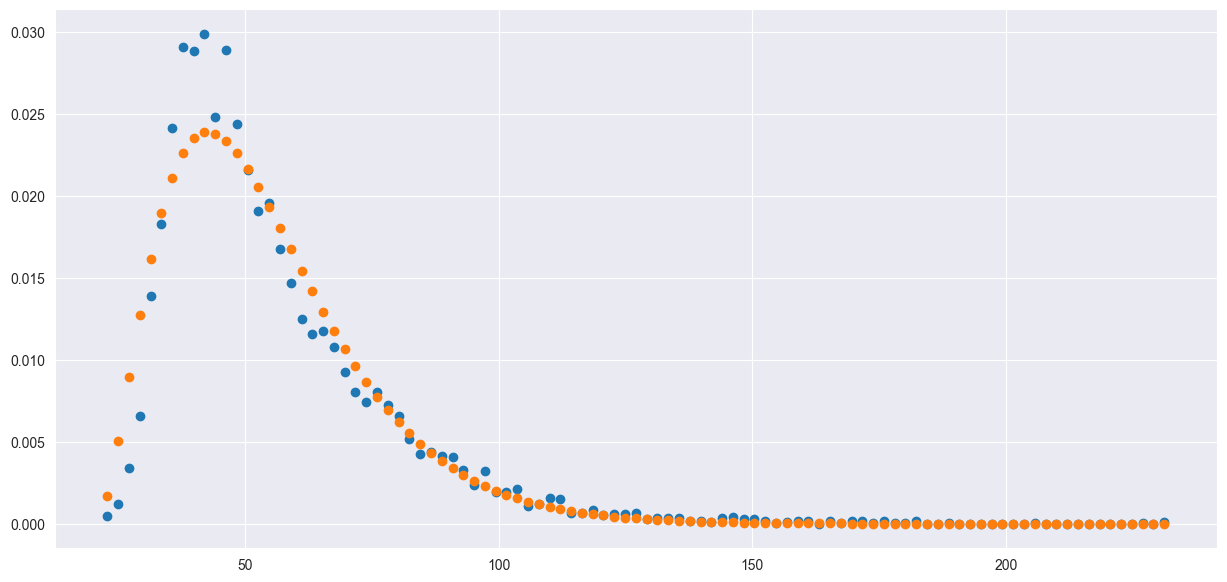

In [41]:
X, y = setupDf("PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 11)